In [13]:
import sagemaker
from sagemaker.sklearn.estimator import SKLearn
from sagemaker.tuner import IntegerParameter, ContinuousParameter, HyperparameterTuner

sess = sagemaker.Session()
role = sagemaker.get_execution_role()
bucket = sess.default_bucket()

# 1. POINT TO YOUR SINGLE CLEANED FILE IN S3
s3_input_uri = "s3://churn-pred-umair/cleaned_data/churn_data_cleaned.csv"

# 2. DEFINE THE VAULT (Where weights will be stored)
# This ensures NOTHING is stored in your local "shared" directory
s3_output_location = "s3://churn-pred-umair/model_weights/output"

# 3. DEFINE ESTIMATOR
sklearn_estimator = SKLearn(
    entry_point='train.py',
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge', 
    framework_version='1.2-1',
    py_version='py3',
    sagemaker_session=sess,
    output_path=s3_output_location  
)

# 4. CONFIGURE HPO
tuner = HyperparameterTuner(
    sklearn_estimator,
    objective_metric_name='auc',
    metric_definitions=[{'Name': 'auc', 'Regex': 'VALIDATION_AUC: ([0-9\\.]+)'}],
    hyperparameter_ranges={
        'n_estimators': IntegerParameter(50, 150),
        'learning_rate': ContinuousParameter(0.01, 0.2)
    },
    max_jobs=6,
    max_parallel_jobs=2,
    strategy='Bayesian'
)

# 5. START
tuner.fit({'train': s3_input_uri})

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment
...........................................................!


In [21]:
# 1. Update your SKLearn Estimator with the BEST parameters
# (Replace 100 and 0.1 with your actual winning values)
import sagemaker
from sagemaker.sklearn.estimator import SKLearn
from sagemaker.tuner import IntegerParameter, ContinuousParameter, HyperparameterTuner

sess = sagemaker.Session()
role = sagemaker.get_execution_role()
bucket = sess.default_bucket()

# 1. POINT TO YOUR SINGLE CLEANED FILE IN S3
s3_input_uri = "s3://churn-pred-umair/cleaned_data/churn_data_cleaned.csv"

# 2. DEFINE THE VAULT (Where weights will be stored)
# This ensures NOTHING is stored in your local "shared" directory
s3_output_location = "s3://churn-pred-umair/model_weights"

final_estimator = SKLearn(
    entry_point='train.py',
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge', 
    framework_version='1.2-1',
    py_version='py3',
    sagemaker_session=sess,
    output_path="s3://churn-pred-umair/model_weights",
    hyperparameters={
        'n_estimators': 100,      # Your HPO Winner value
        'learning_rate': 0.1      # Your HPO Winner value
    }
)

# 2. Start the Single Training Job
# This will create a NEW model.tar.gz that includes your model_fn
final_estimator.fit({'train': s3_input_uri})

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment
2026-03-19 18:12:26 Starting - Starting the training job...
2026-03-19 18:12:40 Starting - Preparing the instances for training...
2026-03-19 18:13:23 Downloading - Downloading the training image......
2026-03-19 18:14:09 Training - Training image download completed. Training in progress./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pk

In [ ]:
# 1. Get the name of the winning training job
best_job_name = tuner.best_training_job()

# 2. Get the full S3 path to that winner's weights
# This solves your "long messy path" problem by finding it for you
best_model_s3 = sess.sagemaker_client.describe_training_job(
    TrainingJobName=best_job_name
)['ModelArtifacts']['S3ModelArtifacts']

print(f"🏆 The Winning Job: {best_job_name}")
print(f"📦 Best Model S3 Path: {best_model_s3}")

In [3]:
# 1. Save X_test to a CSV locally (no index, no header for cleaner inference)
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv("s3://churn-pred-umair/cleaned_data/churn_data_cleaned.csv")

X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


X_test_cleaned = X_test.replace({'True': 1, 'False': 0, 'true': 1, 'false': 0})

In [24]:
import os

import sagemaker



# 1. Initialize the SageMaker Session
sess = sagemaker.Session()

# 2. Get the Execution Role (Permissions)
role = sagemaker.get_execution_role()

bucket = "churn-pred-umair"

X_test.to_csv("batch_inference.csv", index = False, header=False)

batch_input_s3 = sess.upload_data(path = "batch_input.csv", bucket=bucket, key_prefix="batch_inference/data")

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


In [28]:
# 1. Convert all booleans/strings to numbers manually
X_test_numeric = X_test.replace({'True': 1, 'False': 0, 'true': 1, 'false': 0, True: 1, False: 0})

# 2. Save this "Pure Numeric" version
X_test_numeric.to_csv("batch_input_numeric.csv", index=False, header=False)

# 3. Upload THIS version to S3
batch_input_s3 = sess.upload_data(
    path="batch_input_numeric.csv", 
    bucket=bucket, 
    key_prefix="batch_inference/data"
)
print(f"Cleaned data uploaded to: {batch_input_s3}")

Cleaned data uploaded to: s3://churn-pred-umair/batch_inference/data/batch_input_numeric.csv


In [30]:
# 1. Create the Transformer object from your existing 'model'
# If 'model' isn't defined, use the SKLearnModel code from earlier
from sagemaker.sklearn.model import SKLearnModel

# 1. Point to your specific S3 weights (The long path you found earlier)
# Example: "s3://churn-pred-umair/model_weights/output/sagemaker-scikit.../output/model.tar.gz"
 

# 2. Re-create the Model object using those S3 weights
model = SKLearnModel(
    model_data="s3://churn-pred-umair/model_weights/sagemaker-scikit-learn-2026-03-19-18-12-21-463/output/model.tar.gz",
    role=role,
    entry_point='train.py', # Still needs the script to know HOW to run the weights
    framework_version='1.2-1',
    py_version='py3'
)
transformer = model.transformer(
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://churn-pred-umair/batch_inference/output',
    assemble_with='Line',
    accept='text/csv'
)

# 2. Start the actual Job
# This will take about 4-7 minutes to complete
transformer.transform(
    data=batch_input_s3, 
    content_type='text/csv', 
    split_type='Line'
)

print("🚀 Batch Transform Job has started!")
print(f"Check the status here: https://console.aws.amazon.com/sagemaker/home?region={sess.boto_region_name}#/transform-jobs")

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
................................/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-03-19 19:19:44,289 INFO - sagemaker-containers - No GPUs detected (normal if no gpus installed)
2026-03-19 19:19:44,293 INFO - sagemaker-containers - No GPUs detected (normal if no gpus installed)
2026-03-19 19:19:44,293 INFO - sagemaker-containers - nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connect

In [4]:
import pandas as pd

# 1. Load your True/False labels (assuming they are in a 1-column CSV from S3)
# If your file was named 'batch_input_numeric.csv.out'
csv_out_path = "s3://churn-pred-umair/batch_inference/output/batch_input_numeric.csv.out"
predictions_df = pd.read_csv(csv_out_path, header=None, names=['Churn_Prediction'])

# 2. Match them to your X_test (make sure the rows match!)
# We use .reset_index() to ensure the row numbers align 0 to N
results_final = X_test.reset_index(drop=True).copy()
results_final['Is_At_Risk'] = predictions_df['Churn_Prediction']

# 3. Filter for only the customers who are predicted to Churn
at_risk_customers = results_final[results_final['Is_At_Risk'] == True]

print(f"🚨 Alert: Found {len(at_risk_customers)} customers at high risk of churning.")

🚨 Alert: Found 289 customers at high risk of churning.


In [7]:
print(predictions_df.columns)

Index(['Churn_Prediction'], dtype='object')


--- Accuracy Report ---
              precision    recall  f1-score   support

       False       0.84      0.91      0.87      1036
        True       0.68      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



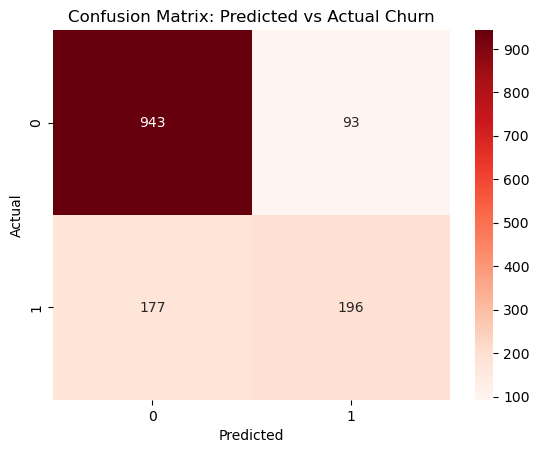

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compare the actual (y_test) vs the predicted (predictions)
y_true = y_test.reset_index(drop=True)

print("--- Accuracy Report ---")
print(classification_report(y_true, predictions_df['Churn_Prediction']))

# Visualize the "Right vs Wrong"
cm = confusion_matrix(y_true, predictions_df['Churn_Prediction'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: Predicted vs Actual Churn')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()